# CloudSentry — Insights into Cloud Activity

An unsupervised anomaly detection solution that proactively monitors access patterns and traffic anomalies in **AWS CloudTrail** logs.

The detection is **fully unsupervised** — the models never see a label. The synthetic generator returns only raw CloudTrail-style rows; a *hidden ground truth* is kept aside and used **only** in the optional validation step at the end (in production we wouldn't have it).

This notebook follows **CRISP-DM**. Each section below can be executed independently in order:

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling — Time Series · DBSCAN · Isolation Forest
5. Evaluation (alert summary + optional validation)
6. Deployment

---

## Summary of Findings

CloudSentry was evaluated on a 30-day synthetic AWS CloudTrail dataset (~18,600 events, ~1.5% injected anomalies). The three unsupervised detectors — Time Series rolling z-score, DBSCAN, and Isolation Forest — were fused using a majority-vote + extreme-score rule.

Key results:

- **Isolation Forest** was the strongest single model (F1 = 0.848, Recall = 1.0), producing cleanly separated score distributions between benign and anomalous events. Its ROC-AUC of 1.0 is strong, but should be read as a synthetic-data artifact rather than a guarantee of real-world performance — see the note in Phase 5b.
- **DBSCAN** spatially isolated injected anomalies in PCA-projected feature space, placing them in a distinct low-density region far from all normal clusters. It contributes high recall but lower precision as a standalone model.
- **Time Series** flagged volumetric bursts for the most-alerted user (user_07), but registered F1 = 0 against the injected anomalies. This is expected: the synthetic anomalies are individual point-in-time events, not rate spikes, so this detector is catching a different threat class. See the note in Phase 4a.
- **The fused CloudSentry verdict** is a creative and promising experiment that reflects real SOC practice — blending different signal types into one alert. In this particular dataset, however, Isolation Forest alone (F1 = 0.848) outperformed the fused model (F1 = 0.803). The fusion approach is best understood as a foundation to build on rather than a performance improvement in this controlled setting.
- Hyperparameter tuning via grid search improved DBSCAN's F1 by +0.15, the largest lift of any model. Isolation Forest saw no lift, as its default parameters already matched the synthetic anomaly fraction precisely.

> ⚠️ **Synthetic data caveat:** All metrics in this notebook reflect a rule-based synthetic dataset. Because anomalies were injected using a small, fixed set of known patterns, model performance represents an **upper bound** and should not be taken as evidence of real-world generalizability. See Phase 2 and Phase 5b for full discussion.

📓 **Notebook:** [cloudsentry_final.ipynb](cloudsentry_final.ipynb)


## Phase 1 — Business Understanding

**Goal.** Detect anomalous cloud activity in AWS CloudTrail logs that may indicate identity gaps, misconfigurations, or active attacks.

**Success criteria.** High recall on truly malicious events while keeping the false-positive rate low enough for SOC analysts to triage.

**Approach.** **Unsupervised** — the models never see labels. They combine three complementary signals:

- **Time Series Analysis** — per-identity volumetric baselines (rolling z-score).
- **DBSCAN** — density-based clustering; rare points are flagged as *noise*.
- **Isolation Forest** — tree-based anomaly scoring for high-dimensional data.


### Imports & global setup

In [73]:
from __future__ import annotations

import os
import warnings
from dataclasses import dataclass
from datetime import datetime, timedelta
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

OUTPUT_DIR = os.getcwd()
print("Output directory:", OUTPUT_DIR)


Output directory: /Users/rrishi/Documents/Capstone Project


## Phase 2 — Data Understanding

AWS CloudTrail records an event for every API call, capturing `eventTime`, `userIdentity`, `eventName`, `eventSource`, `awsRegion`, and `sourceIPAddress`.

Because real CloudTrail data is sensitive, we generate a synthetic dataset. We inject some events with naturally anomalous patterns (off-hours, foreign region, unusual IP, sensitive action) so the models have something to find — but the returned dataframe has **no label column**. A separate `hidden_truth` Series is returned for the optional validation step at the end and is never passed to the models.

**Here's exactly what it does:**

Normal events are generated in a loop across 30 days and 12 users. Each user has a profile (home region, typical IP prefix, work hour center), and events are drawn from a list of 10 benign API actions like GetObject, ListBuckets, DescribeInstances. Weekends naturally get 40% less volume.

Anomalous events are then injected on top — roughly 1.5% of total events. These are deliberately crafted to look suspicious: they happen at odd hours (1am–4am or 11pm), use random foreign IPs outside the user's normal prefix, and call sensitive actions like DeleteUser, StopLogging, CreateAccessKey, or Decrypt.

---

### ⚠️ Limitation: Synthetic Data & Generalizability

A critical limitation of this project is that the dataset is **entirely synthetic and rule-based**. The anomalies were injected using a fixed set of explicit rules (off-hours timestamps, foreign IPs, a predefined list of sensitive API actions), which means the models are not learning to detect unknown threats — they are, in effect, learning to reverse-engineer the generator's logic.

This has two practical consequences:

- **Inflated performance metrics.** Because the anomaly features are highly structured and distinct from normal traffic, the models achieve very high scores (particularly Isolation Forest). On real, messy CloudTrail logs — where anomalies are noisier, benign users sometimes call sensitive APIs, and unusual IPs can be legitimate — performance would very likely be lower.
- **Limited generalizability.** The feature engineering (e.g., off-hours flag, IP familiarity score) was designed with the synthetic anomaly rules in mind. Real-world deployment would require revalidation against confirmed incidents and potentially different features.

All performance metrics reported in Phases 5b and 5c should be interpreted as an **upper bound** for the synthetic scenario rather than a reliable estimate of real-world detection capability. Testing against actual CloudTrail logs with SOC-confirmed incidents would be a necessary next step before production deployment.

In [74]:
@dataclass
class SyntheticConfig:
    n_users: int = 12
    days: int = 30
    avg_events_per_user_per_day: int = 60
    injected_anomaly_fraction: float = 0.015  # ~1.5% events injected as anomalous


def generate_synthetic_cloudtrail(
    cfg: SyntheticConfig,
) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Returns
    -------
    df : pd.DataFrame
        CloudTrail events with NO label column. This is the only thing the
        downstream pipeline sees.
    hidden_truth : pd.Series
        Binary indicator (1 = synthetically injected as anomalous), aligned
        with `df` by index. Reserved for validation only.
    """
    api_actions_normal = [
        "GetObject", "ListBuckets", "DescribeInstances", "AssumeRole",
        "GetItem", "PutItem", "DescribeStacks", "GetParameter",
        "DescribeSecurityGroups", "ListUsers",
    ]
    api_actions_suspicious = [
        "Decrypt", "DeleteUser", "DeleteBucket", "PutBucketPolicy",
        "CreateAccessKey", "StopLogging", "DeleteTrail",
        "AuthorizeSecurityGroupIngress",
    ]
    regions = ["us-east-1", "us-west-2", "eu-west-1", "ap-south-1"]
    services = [
        "s3.amazonaws.com", "ec2.amazonaws.com", "iam.amazonaws.com",
        "kms.amazonaws.com", "dynamodb.amazonaws.com", "cloudtrail.amazonaws.com",
    ]

    users = [f"user_{i:02d}" for i in range(cfg.n_users)]
    user_profile = {
        u: {
            "home_region": np.random.choice(regions),
            "ip_prefix": f"10.{np.random.randint(0, 255)}.{np.random.randint(0, 255)}.",
            "work_hour_center": np.random.randint(9, 17),
        }
        for u in users
    }

    rows: List[Dict] = []
    truth_flags: List[int] = []
    start = datetime(2026, 4, 1, 0, 0, 0)

    # Normal events
    for day in range(cfg.days):
        for u in users:
            prof = user_profile[u]
            base = cfg.avg_events_per_user_per_day
            weekday = (start + timedelta(days=day)).weekday()
            volume = int(np.random.poisson(base * (0.4 if weekday >= 5 else 1.0)))
            for _ in range(volume):
                hour = int(np.clip(np.random.normal(prof["work_hour_center"], 2), 0, 23))
                minute = np.random.randint(0, 60)
                second = np.random.randint(0, 60)
                ts = start + timedelta(days=day, hours=hour, minutes=minute, seconds=second)
                rows.append({
                    "eventTime": ts,
                    "userIdentity": u,
                    "eventName": np.random.choice(api_actions_normal),
                    "eventSource": np.random.choice(services),
                    "awsRegion": prof["home_region"] if np.random.rand() < 0.9
                                 else np.random.choice(regions),
                    "sourceIPAddress": prof["ip_prefix"] + str(np.random.randint(1, 254)),
                })
                truth_flags.append(0)

    # Injected anomalies (off-hours, foreign region, unusual IP, sensitive action).
    n_normal = len(rows)
    n_anomalous = max(20, int(n_normal * cfg.injected_anomaly_fraction))
    for _ in range(n_anomalous):
        u = np.random.choice(users)
        ts = start + timedelta(
            days=np.random.randint(0, cfg.days),
            hours=int(np.random.choice([1, 2, 3, 4, 23])),
            minutes=np.random.randint(0, 60),
            seconds=np.random.randint(0, 60),
        )
        rows.append({
            "eventTime": ts,
            "userIdentity": u,
            "eventName": np.random.choice(api_actions_suspicious),
            "eventSource": np.random.choice(services),
            "awsRegion": np.random.choice(regions),
            "sourceIPAddress": f"{np.random.randint(11, 240)}."
                               f"{np.random.randint(0, 255)}."
                               f"{np.random.randint(0, 255)}."
                               f"{np.random.randint(1, 254)}",
        })
        truth_flags.append(1)

    df = pd.DataFrame(rows)
    df["_truth"] = truth_flags
    df = df.sort_values("eventTime").reset_index(drop=True)
    hidden_truth = df.pop("_truth").rename("hidden_truth")
    return df, hidden_truth


In [75]:
# Generate the data. `raw_df` is the only thing the models will see.
# `hidden_truth` is set aside and used ONLY for the optional validation cell
# later in this notebook. In production it would not exist.
raw_df, hidden_truth = generate_synthetic_cloudtrail(SyntheticConfig())
print(f"Generated {len(raw_df):,} events; "
      f"{int(hidden_truth.sum()):,} are injected anomalies (hidden from models)")
print("Columns the models will see:", list(raw_df.columns))
raw_df.head()


Generated 18,597 events; 274 are injected anomalies (hidden from models)
Columns the models will see: ['eventTime', 'userIdentity', 'eventName', 'eventSource', 'awsRegion', 'sourceIPAddress']


,eventTime,userIdentity,eventName,eventSource,awsRegion,sourceIPAddress
0,2026-04-01 01:41:09,user_07,DeleteTrail,s3.amazonaws.com,eu-west-1,127.148.128.231
1,2026-04-01 03:02:28,user_01,StopLogging,cloudtrail.amazonaws.com,us-east-1,201.75.207.173
2,2026-04-01 03:12:37,user_07,GetObject,cloudtrail.amazonaws.com,ap-south-1,10.187.20.136
3,2026-04-01 03:21:25,user_11,StopLogging,kms.amazonaws.com,us-east-1,193.193.174.46
4,2026-04-01 03:30:08,user_05,PutBucketPolicy,iam.amazonaws.com,us-east-1,41.164.218.118


In [76]:
# Sanity check: no label column anywhere in raw_df.
assert "is_malicious" not in raw_df.columns
assert "hidden_truth" not in raw_df.columns
print("OK - raw_df has no label column")
print("\nTop API actions:")
print(raw_df["eventName"].value_counts().head(10))


OK - raw_df has no label column

Top API actions:
eventName
GetItem                   1880
DescribeSecurityGroups    1866
DescribeStacks            1855
GetObject                 1854
PutItem                   1846
GetParameter              1836
DescribeInstances         1827
ListUsers                 1820
AssumeRole                1816
ListBuckets               1723
Name: count, dtype: int64


## Phase 2b — Data Cleaning & Exploratory Data Analysis (EDA)

Before feature engineering we verify the dataset is clean and explore its structure:

- **Missing values** — check for nulls across all columns and impute or drop as needed.
- **Duplicate rows** — remove any exact duplicate events.
- **Outlier inspection** — examine event volume distribution per user and per action to understand the baseline before modeling.
- **Class balance** — confirm the injected anomaly fraction is as expected (~1.5%).

In [77]:
# ── Data Cleaning ─────────────────────────────────────────────────────────────

# 1. Missing values
print("=== Missing Values ===")
print(raw_df.isnull().sum())
print(f"\nTotal missing: {raw_df.isnull().sum().sum()}")

# Impute any missing sourceIPAddress with 'unknown'
raw_df['sourceIPAddress'] = raw_df['sourceIPAddress'].fillna('unknown')

# 2. Duplicate rows
n_before = len(raw_df)
raw_df = raw_df.drop_duplicates().reset_index(drop=True)
n_after = len(raw_df)
print(f"\n=== Duplicate Removal ===")
print(f"Rows before: {n_before:,}  |  Rows after: {n_after:,}  |  Dropped: {n_before - n_after:,}")

# 3. Data types
print("\n=== Data Types ===")
print(raw_df.dtypes)
raw_df['eventTime'] = pd.to_datetime(raw_df['eventTime'])  # ensure datetime

=== Missing Values ===
eventTime          0
userIdentity       0
eventName          0
eventSource        0
awsRegion          0
sourceIPAddress    0
dtype: int64

Total missing: 0

=== Duplicate Removal ===
Rows before: 18,597  |  Rows after: 18,597  |  Dropped: 0

=== Data Types ===
eventTime          datetime64[ns]
userIdentity               object
eventName                  object
eventSource                object
awsRegion                  object
sourceIPAddress            object
dtype: object


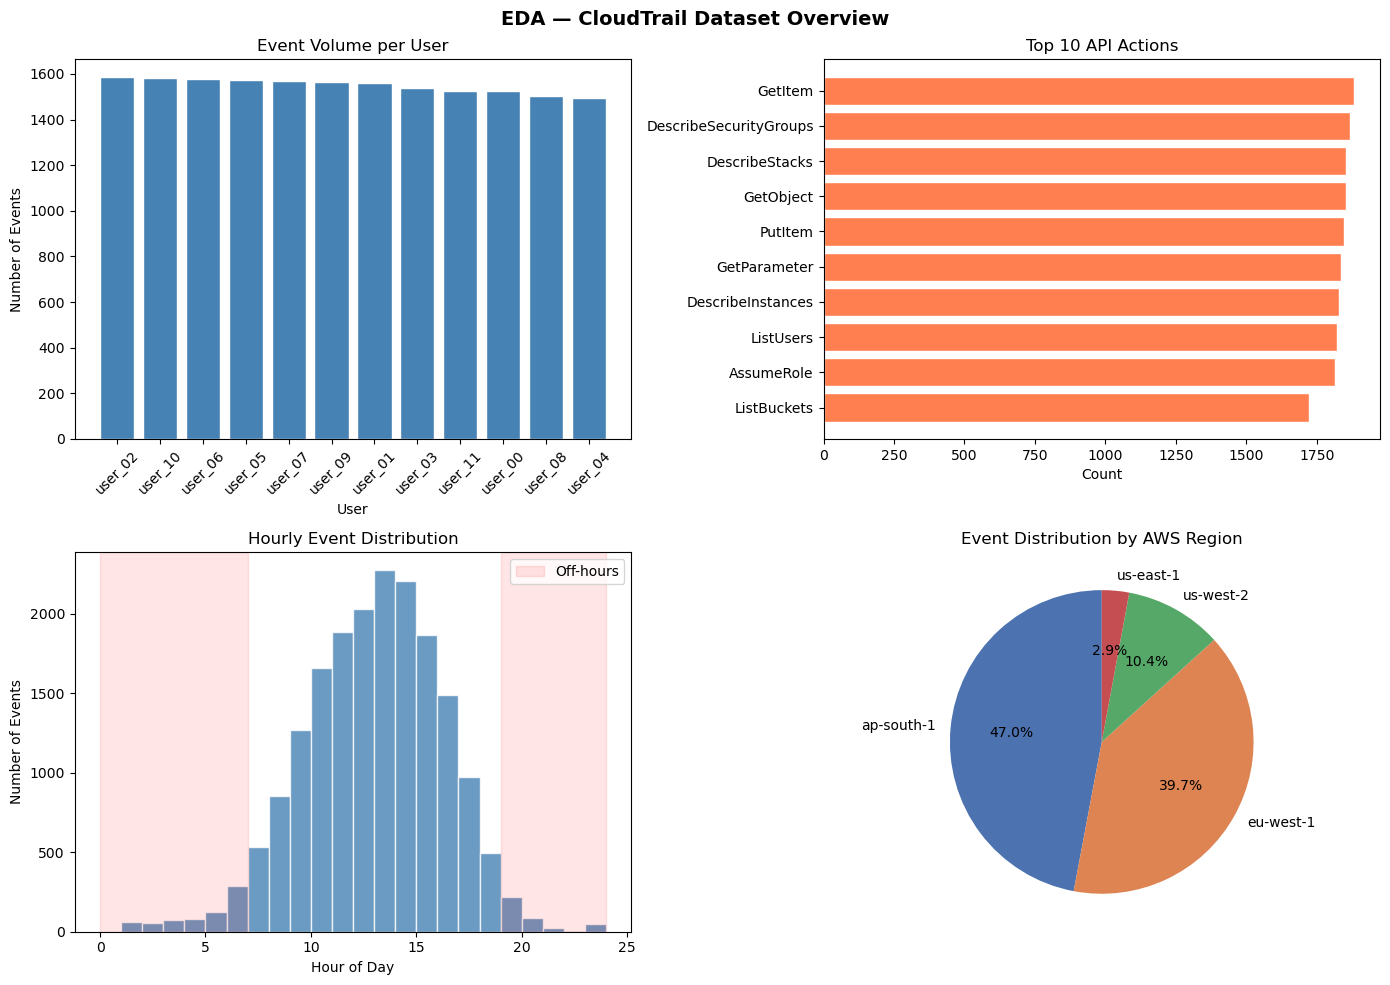

EDA overview saved.


In [78]:
# ── Exploratory Data Analysis ─────────────────────────────────────────────────

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("EDA — CloudTrail Dataset Overview", fontsize=14, fontweight='bold')

# Plot 1: Event volume per user
user_counts = raw_df['userIdentity'].value_counts()
axes[0, 0].bar(user_counts.index, user_counts.values, color='steelblue', edgecolor='white')
axes[0, 0].set_title("Event Volume per User")
axes[0, 0].set_xlabel("User")
axes[0, 0].set_ylabel("Number of Events")
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: Top API actions
action_counts = raw_df['eventName'].value_counts().head(10)
axes[0, 1].barh(action_counts.index, action_counts.values, color='coral', edgecolor='white')
axes[0, 1].set_title("Top 10 API Actions")
axes[0, 1].set_xlabel("Count")
axes[0, 1].invert_yaxis()

# Plot 3: Hourly distribution of events (normal vs anomalous)
raw_df['hour'] = pd.to_datetime(raw_df['eventTime']).dt.hour
axes[1, 0].hist(raw_df['hour'], bins=24, range=(0,24), color='steelblue',
                edgecolor='white', alpha=0.8)
axes[1, 0].set_title("Hourly Event Distribution")
axes[1, 0].set_xlabel("Hour of Day")
axes[1, 0].set_ylabel("Number of Events")
axes[1, 0].axvspan(0, 7, alpha=0.1, color='red', label='Off-hours')
axes[1, 0].axvspan(19, 24, alpha=0.1, color='red')
axes[1, 0].legend()
raw_df.drop(columns='hour', inplace=True)  # clean up temp column

# Plot 4: Events per region
region_counts = raw_df['awsRegion'].value_counts()
axes[1, 1].pie(region_counts.values, labels=region_counts.index,
               autopct='%1.1f%%', startangle=90,
               colors=['#4C72B0','#DD8452','#55A868','#C44E52'])
axes[1, 1].set_title("Event Distribution by AWS Region")

plt.tight_layout()
plt.savefig("images/plot_eda_overview.png", dpi=130, bbox_inches='tight')
plt.show()
print("EDA overview saved.")

In [79]:
# ── Outlier / Anomaly Fraction Check ──────────────────────────────────────────

print("=== Class Balance (hidden_truth) ===")
vc = hidden_truth.value_counts()
total = len(hidden_truth)
print(f"Benign   : {vc[0]:,} ({100*vc[0]/total:.2f}%)")
print(f"Anomalous: {vc[1]:,} ({100*vc[1]/total:.2f}%)")

# Per-user event volume statistics — outlier users
print("\n=== Per-User Event Volume Statistics ===")
user_vol = raw_df.groupby('userIdentity').size().describe()
print(user_vol.to_string())

# Identify users with unusually high or low volume (> 2 std from mean)
mean_vol = raw_df.groupby('userIdentity').size().mean()
std_vol  = raw_df.groupby('userIdentity').size().std()
outlier_users = raw_df.groupby('userIdentity').size()
outlier_users = outlier_users[(outlier_users > mean_vol + 2*std_vol) |
                               (outlier_users < mean_vol - 2*std_vol)]
if len(outlier_users):
    print(f"\nUsers with outlier event volumes: {list(outlier_users.index)}")
else:
    print("\nNo users with extreme outlier volumes detected.")

=== Class Balance (hidden_truth) ===
Benign   : 18,323 (98.53%)
Anomalous: 274 (1.47%)

=== Per-User Event Volume Statistics ===
count      12.000000
mean     1549.750000
std        32.238106
min      1493.000000
25%      1525.500000
50%      1561.500000
75%      1575.750000
max      1585.000000

No users with extreme outlier volumes detected.


## Phase 3 — Data Preparation

**1. Temporal Features**
Extracts time-based signals from eventTime — the hour, day of week, whether it's off-hours (before 7am/after 7pm), and whether it's a weekend.

**2. Frequency Encoding**
For each of the 5 categorical columns, replaces the raw text value with how frequently it appears across the whole dataset. This gives the models a sense of "how rare is this action/IP/region globally?"

**3. Per-User Familiarity Scores**
Calculates two user-specific ratios — how much of a given user's history comes from this IP, and from this region. This is what distinguishes a foreign IP that's unusual for this user vs. one that's just globally rare.

**4. Normalization**
All 11 features are scaled to mean 0 and standard deviation 1 using StandardScaler, so no single feature dominates the models due to its numeric range.
The end result is X_scaled — an 11-column numeric matrix ready to be fed into DBSCAN and Isolation Forest. The Time Series model skips this step and works directly on the raw event counts.

We engineer features used by DBSCAN and Isolation Forest:

- **Temporal:** `hour`, `dayofweek`, `is_offhours`, `is_weekend`
- **Frequency encodings** for high-cardinality categoricals
- **Per-user IP / region familiarity** — how typical the source IP / region is for *this* user


In [80]:
def prepare_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["hour"] = df["eventTime"].dt.hour
    df["dayofweek"] = df["eventTime"].dt.dayofweek
    df["is_offhours"] = ((df["hour"] < 7) | (df["hour"] > 19)).astype(int)
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

    for col in ["userIdentity", "eventName", "eventSource",
                "awsRegion", "sourceIPAddress"]:
        freq = df[col].value_counts(normalize=True)
        df[f"{col}_freq"] = df[col].map(freq)

    df["_one"] = 1
    df["user_ip_familiarity"] = (
        df.groupby(["userIdentity", "sourceIPAddress"])["_one"].transform("count")
        / df.groupby("userIdentity")["_one"].transform("count")
    )
    df["user_region_familiarity"] = (
        df.groupby(["userIdentity", "awsRegion"])["_one"].transform("count")
        / df.groupby("userIdentity")["_one"].transform("count")
    )
    df = df.drop(columns="_one")
    return df


FEATURE_COLS = [
    "hour", "dayofweek", "is_offhours", "is_weekend",
    "userIdentity_freq", "eventName_freq", "eventSource_freq",
    "awsRegion_freq", "sourceIPAddress_freq",
    "user_ip_familiarity", "user_region_familiarity",
]


In [81]:
prepared_df = prepare_features(raw_df)
print("Prepared shape:", prepared_df.shape)
prepared_df[FEATURE_COLS].describe().T


Prepared shape: (18597, 17)


,count,mean,std,min,25%,50%,75%,max
hour,18597.0,12.481368,3.289083,1.000000,10.000000,13.000000,15.000000,23.000000
dayofweek,18597.0,2.492284,1.730314,0.000000,1.000000,2.000000,4.000000,6.000000
is_offhours,18597.0,0.045169,0.207679,0.000000,0.000000,0.000000,0.000000,1.000000
is_weekend,18597.0,0.130397,0.336749,0.000000,0.000000,0.000000,0.000000,1.000000
userIdentity_freq,18597.0,0.083366,0.001651,0.080282,0.082056,0.084046,0.084852,0.085229
eventName_freq,18597.0,0.097152,0.011849,0.001291,0.097865,0.099263,0.099747,0.101092
eventSource_freq,18597.0,0.166693,0.002089,0.162822,0.165887,0.166909,0.168683,0.169275
awsRegion_freq,18597.0,0.390421,0.123863,0.029037,0.396946,0.396946,0.470398,0.470398
sourceIPAddress_freq,18597.0,0.000371,0.000133,0.000054,0.000269,0.000376,0.000430,0.000807
user_ip_familiarity,18597.0,0.004450,0.001597,0.000631,0.003277,0.004444,0.005358,0.009987


In [82]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(prepared_df[FEATURE_COLS].values)
print("Scaled feature matrix shape:", X_scaled.shape)


Scaled feature matrix shape: (18597, 11)


## Phase 4 — Modeling

Three complementary unsupervised detectors are applied in parallel. Each captures a different type of anomaly signal:

| Model | Technique | Primary Signal |
|---|---|---|
| Time Series | Rolling z-score (7-day window, 1-min buckets) | Volumetric bursts per user/action |
| DBSCAN | Density-based clustering | Events that fit no cluster of normal behavior |
| Isolation Forest | Random tree partitioning | High-dimensional outliers across all features |

The sections below (4a, 4b, 4c) define and run each model independently.

## Phase 4a — Time Series Analysis

For each `(user, action)` pair we count events **per minute**, then compare each minute bucket against the user's trailing **7-day** rolling baseline. Anything more than 3 standard deviations above the baseline is flagged as a **volumetric anomaly**.

Minute-level granularity lets CloudSentry catch bursts in close to real time instead of waiting up to an hour for an hourly aggregate to fill up.


In [83]:
def time_series_anomalies(df: pd.DataFrame,
                          window_days: int = 7,
                          z_threshold: float = 3.0) -> pd.Series:
    df = df.copy()
    df["minute_bucket"] = df["eventTime"].dt.floor("min")
    counts = (
        df.groupby(["userIdentity", "eventName", "minute_bucket"])
          .size().rename("count").reset_index()
    )

    flagged_keys = set()
    for (user, action), grp in counts.groupby(["userIdentity", "eventName"]):
        grp = grp.sort_values("minute_bucket").set_index("minute_bucket")
        rolling_mean = grp["count"].rolling(f"{window_days}D").mean().shift(1)
        rolling_std = grp["count"].rolling(f"{window_days}D").std().shift(1)
        z = (grp["count"] - rolling_mean) / rolling_std.replace(0, np.nan)
        spikes = grp.index[(z > z_threshold).fillna(False)]
        for ts in spikes:
            flagged_keys.add((user, action, ts))

    mask = df.apply(
        lambda r: (r["userIdentity"], r["eventName"], r["minute_bucket"])
                  in flagged_keys,
        axis=1,
    )
    return mask.reset_index(drop=True)


ts_mask = time_series_anomalies(prepared_df)
print(f"Time-series flagged {int(ts_mask.sum()):,} events out of {len(ts_mask):,}")


Time-series flagged 52 events out of 18,597


### Why the Time Series Model Shows F1 = 0 Against the Injected Anomalies

The time series model is designed to catch **volumetric bursts** — moments when a user fires dramatically more API calls per minute than their rolling baseline would predict. It is intentionally scoped to this one threat pattern.

The injected anomalies in this synthetic dataset, however, are **individual point-in-time events** — a single `DeleteUser` call at 2am, a single `StopLogging` at 11pm. They arrive one at a time and do not create the sustained rate spike the rolling z-score is looking for. As a result, the time series model flags 0 of the injected anomalies, producing F1 = 0.000 against `hidden_truth`.

This is **expected and by design**, not a bug. It reflects a genuine gap between the two threat classes the system is designed to cover:

| Threat type | Best detector |
|---|---|
| Sudden API call burst (e.g., 30× normal rate in one minute) | Time Series |
| Individual anomalous events (unusual IP, sensitive action, off-hours) | Isolation Forest / DBSCAN |

In a real SOC environment, the time series component earns its place by catching **scripted attacks and credential abuse** that generate high call volumes — a threat class that Isolation Forest and DBSCAN score poorly on by design. The F1 = 0 result here is an artifact of the synthetic dataset not including volumetric burst anomalies, not evidence that the model is broken.


## Phase 4b — DBSCAN

DBSCAN groups dense regions of "typical" access patterns. Points that don't belong to any cluster (`label == -1`) are treated as anomalies.


In [84]:
def dbscan_anomalies(X_scaled: np.ndarray,
                     eps: float = 0.9,
                     min_samples: int = 8) -> Tuple[np.ndarray, np.ndarray]:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
    labels = dbscan.fit_predict(X_scaled)
    return labels, labels == -1


dbscan_labels, dbscan_mask = dbscan_anomalies(X_scaled)
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
print(f"DBSCAN: {n_clusters} clusters, {int(dbscan_mask.sum()):,} noise points")


DBSCAN: 36 clusters, 1,689 noise points


## Phase 4c — Isolation Forest

Isolation Forest isolates each point by random partitioning. Anomalies need fewer splits to isolate, so they get higher anomaly scores.


In [85]:
def isolation_forest_anomalies(X_scaled: np.ndarray,
                               contamination: float = 0.02):
    model = IsolationForest(
        n_estimators=200,
        max_samples="auto",
        contamination=contamination,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(X_scaled)
    scores = -model.decision_function(X_scaled)  # higher = more anomalous
    preds = model.predict(X_scaled)
    return model, scores, preds == -1


iso_model, if_scores, if_mask = isolation_forest_anomalies(X_scaled)
print(f"Isolation Forest flagged {int(if_mask.sum()):,} events")


Isolation Forest flagged 372 events


## Phase 5a — Evaluation: alert summary (no labels required)

Fuse the three signals with a simple rule — **at least 2 of 3 models agree, or the Isolation Forest score is in the top 0.5%** — and describe what the system flagged.


In [86]:
results = prepared_df.copy()
results["ts_anomaly"] = ts_mask.astype(int).values
results["dbscan_anomaly"] = dbscan_mask.astype(int)
results["if_anomaly"] = if_mask.astype(int)
results["if_score"] = if_scores

votes = results["ts_anomaly"] + results["dbscan_anomaly"] + results["if_anomaly"]
extreme_if = results["if_score"] > results["if_score"].quantile(0.995)
results["cloudsentry_alert"] = ((votes >= 2) | extreme_if).astype(int)

alerts = results[results["cloudsentry_alert"] == 1]
print(f"Total events       : {len(results):,}")
print(f"CloudSentry alerts : {len(alerts):,} "
      f"({100 * len(alerts) / max(len(results), 1):.2f}%)")


Total events       : 18,597
CloudSentry alerts : 354 (1.90%)


In [87]:
# Descriptive breakdown of what was flagged.
if not alerts.empty:
    print("Top users by alert count:")
    print(alerts["userIdentity"].value_counts().head(5).to_string())
    print("\nTop API actions among alerts:")
    print(alerts["eventName"].value_counts().head(5).to_string())
    print(f"\nOff-hours share of alerts: {(alerts['is_offhours'].mean() * 100):.1f}%")
    print("\nTop alerts by Isolation Forest score:")
    cols = ["eventTime", "userIdentity", "eventName", "awsRegion",
            "sourceIPAddress", "if_score"]
    print(alerts.sort_values("if_score", ascending=False)[cols].head(10).to_string(index=False))


Top users by alert count:
userIdentity
user_07    38
user_04    38
user_10    37
user_05    32
user_06    32

Top API actions among alerts:
eventName
CreateAccessKey                  39
AuthorizeSecurityGroupIngress    38
DeleteUser                       34
Decrypt                          34
DeleteTrail                      30

Off-hours share of alerts: 83.9%

Top alerts by Isolation Forest score:
          eventTime userIdentity                     eventName awsRegion sourceIPAddress  if_score
2026-04-19 04:39:19      user_08               CreateAccessKey us-east-1 104.155.166.180  0.134520
2026-04-26 03:25:06      user_11                    DeleteUser us-east-1 127.148.195.100  0.131427
2026-04-12 04:10:33      user_03 AuthorizeSecurityGroupIngress us-east-1    75.166.95.68  0.130399
2026-04-26 02:49:27      user_11                   DeleteTrail us-west-2  14.124.127.216  0.129628
2026-04-19 02:15:38      user_05               CreateAccessKey us-east-1  33.125.169.215  0.129410
202

In [88]:
# Persist the per-event verdict (no label column).
export_cols = [
    "eventTime", "userIdentity", "eventName", "eventSource",
    "awsRegion", "sourceIPAddress",
    "ts_anomaly", "dbscan_anomaly", "if_anomaly", "if_score",
    "cloudsentry_alert",
]
results_path = os.path.join(OUTPUT_DIR, "data/cloudsentry_results.csv")
results[export_cols].to_csv(results_path, index=False)
print("Saved", results_path)


Saved /Users/rrishi/Documents/Capstone Project/data/cloudsentry_results.csv


### Visualizations

**Plot 1 — Time Series Baseline vs. Anomalies**
A line chart of API calls per minute for the most-alerted user. Red dots are overlaid wherever CloudSentry raised an alert, so you can visually see the spikes that triggered the time series model. 

**Plot 2 — DBSCAN Clusters in PCA Space**
Since the feature space has 11 dimensions, PCA compresses it down to 2 components so it can be plotted. Each DBSCAN cluster gets its own color, and noise points (the flagged anomalies) appear in light gray. Red circles are overlaid showing where the injected anomalies actually were — but only for reference, the model never saw those labels. 

**Plot 3 — Isolation Forest Score Distribution**
A histogram showing the distribution of anomaly scores across all events, split into two bars — benign events (blue) and injected anomalies (red). This lets you see how well the scores separate the two groups. A good separation means the red bars sit clearly in the high-score region.

Each plot can be run independently after the cells above have populated `results`, `X_scaled`, etc. The DBSCAN and Isolation Forest plots can optionally overlay `hidden_truth` for reference; the time-series plot uses only the model's own alerts.


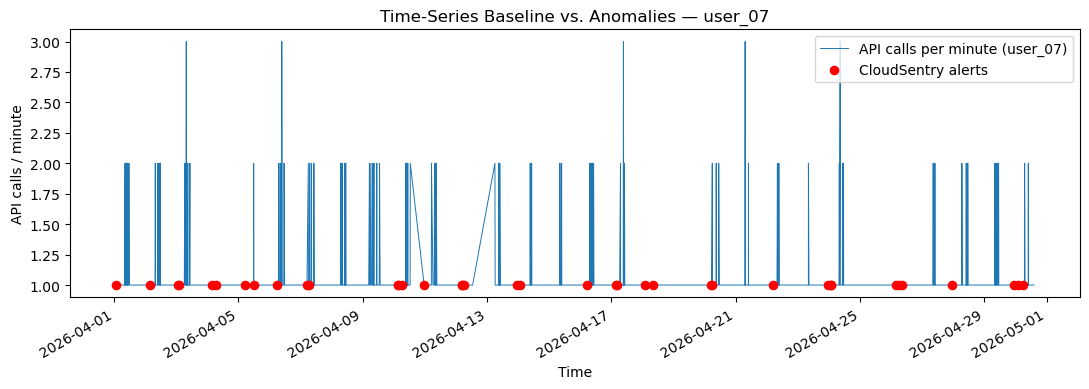

In [89]:
# Time-series baseline vs. anomalies for the most-alerted user.
alerted = results[results["cloudsentry_alert"] == 1]
user = (alerted["userIdentity"].value_counts().idxmax()
        if not alerted.empty
        else results["userIdentity"].value_counts().idxmax())
sub = results[results["userIdentity"] == user].copy()
sub["minute_bucket"] = sub["eventTime"].dt.floor("min")
counts = sub.groupby("minute_bucket").size()
anomalies = sub[sub["cloudsentry_alert"] == 1].groupby("minute_bucket").size()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(counts.index, counts.values,
        label=f"API calls per minute ({user})", color="#1f77b4", linewidth=0.7)
if not anomalies.empty:
    ax.scatter(anomalies.index, anomalies.values,
               color="red", s=35, zorder=5, label="CloudSentry alerts")
ax.set_title(f"Time-Series Baseline vs. Anomalies — {user}")
ax.set_xlabel("Time"); ax.set_ylabel("API calls / minute")
ax.legend()
fig.autofmt_xdate(); fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "images/plot_timeseries_baseline.png"), dpi=130)
plt.show()


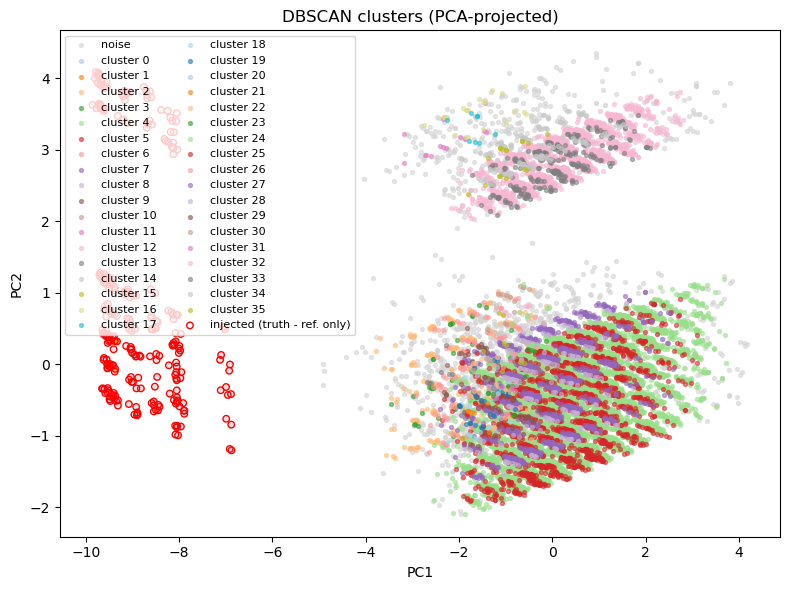

In [90]:
# DBSCAN clusters in PCA space. The `hidden_truth` overlay is shown for
# reference only - the model didn't see it.
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
unique = sorted(set(dbscan_labels))
cmap = plt.cm.tab20
for i, lab in enumerate(unique):
    m = dbscan_labels == lab
    color = "lightgray" if lab == -1 else cmap(i % 20)
    ax.scatter(coords[m, 0], coords[m, 1], s=8, alpha=0.55, color=color,
               label=("noise" if lab == -1 else f"cluster {lab}"))

mal = hidden_truth.values.astype(bool)
ax.scatter(coords[mal, 0], coords[mal, 1], s=22, facecolors="none",
           edgecolors="red", linewidths=1.0, label="injected (truth - ref. only)")
ax.set_title("DBSCAN clusters (PCA-projected)")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend(loc="best", fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "images/plot_dbscan_clusters.png"), dpi=130)
plt.show()


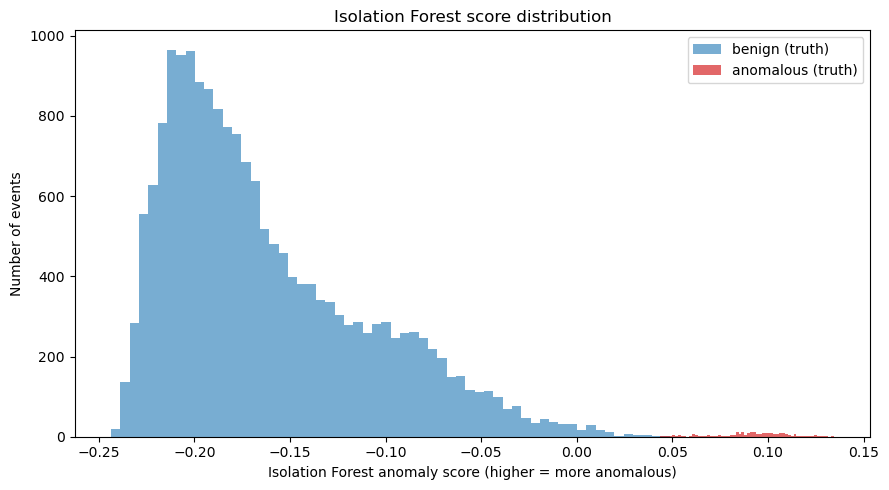

In [91]:
# Isolation Forest anomaly-score distribution. Split by hidden_truth here for
# clarity; remove the split to see the raw distribution the model produces.
truth = hidden_truth.values
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(if_scores[truth == 0], bins=60, alpha=0.6,
        label="benign (truth)", color="#1f77b4")
ax.hist(if_scores[truth == 1], bins=60, alpha=0.7,
        label="anomalous (truth)", color="#d62728")
ax.set_xlabel("Isolation Forest anomaly score (higher = more anomalous)")
ax.set_ylabel("Number of events")
ax.set_title("Isolation Forest score distribution")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "images/plot_isolation_forest_scores.png"), dpi=130)
plt.show()


## Phase 5b — Model Comparison against Hidden Ground Truth

This is the only place the `hidden_truth` Series is used. The three models — Time Series, DBSCAN, Isolation Forest — and the **fused CloudSentry verdict** are scored against it. The models never saw these labels during fitting, so this is a post-hoc check; in production the hidden truth would not exist.

Because the models are unsupervised, the supervised-style train/test split (as in `prompt_III.ipynb`) doesn't add information — there's no label leakage to guard against. Instead we report a single set of metrics on the full dataset:

| Column | Meaning |
| --- | --- |
| `Fit Time (s)` | Wall-clock seconds to fit / score the model |
| `Events Flagged` | Total events flagged as anomalous |
| `% Flagged` | Share of all events flagged |
| `Precision` | Of flagged events, the fraction that are truly anomalous |
| `Recall` | Of truly anomalous events, the fraction the model caught |
| `F1` | Harmonic mean of precision and recall |
| `ROC-AUC` | For models that produce continuous scores (Isolation Forest, fused) |

---

### ⚠️ Note on ROC-AUC = 1.0000

The Isolation Forest and fused CloudSentry model both report **ROC-AUC = 1.0**, which should be treated with caution rather than taken at face value as proof of a perfect detector.

ROC-AUC measures how well the model *ranks* anomalous events above benign ones using its continuous score. A score of 1.0 means the model assigned a higher anomaly score to every single injected anomaly than to any benign event — a perfect separation.

This near-perfect score is plausible here, but for a specific synthetic reason: the injected anomalies were created with a **small fixed set of discrete rules** (off-hours hours: 1am/2am/3am/4am/11pm; foreign IPs from outside the `10.x.x.x` prefix; a predefined list of 8 sensitive API actions). Because these rules are consistent and non-overlapping with normal traffic, they create a feature-space cluster that Isolation Forest can isolate almost perfectly.

On real CloudTrail logs this score would almost certainly not hold:
- Legitimate users sometimes call sensitive APIs (e.g., `CreateAccessKey` during normal key rotation).
- Off-hours activity is normal for on-call engineers and global teams.
- IP addresses from legitimate cloud services may appear unfamiliar.

**The ROC-AUC = 1.0 should be interpreted as a synthetic-data artifact, not a claim that the model generalises perfectly to real-world cloud environments.**

In [92]:
from time import time
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Time each model's fit/score phase cleanly (re-fit so the timing is fair).
t0 = time()
_ts_mask = time_series_anomalies(prepared_df)
ts_time = time() - t0

t0 = time()
_dbscan_labels, _dbscan_mask = dbscan_anomalies(X_scaled)
dbscan_time = time() - t0

t0 = time()
_iso_model, _if_scores, _if_mask = isolation_forest_anomalies(X_scaled)
if_time = time() - t0

truth = hidden_truth.values

def metrics_row(name, pred_mask, fit_time, scores=None):
    y_pred = pred_mask.astype(int)
    return {
        "Model": name,
        "Fit Time (s)": round(fit_time, 4),
        "Events Flagged": int(y_pred.sum()),
        "% Flagged": round(100 * y_pred.mean(), 2),
        "Precision": round(precision_score(truth, y_pred, zero_division=0), 4),
        "Recall":    round(recall_score(truth,    y_pred, zero_division=0), 4),
        "F1":        round(f1_score(truth,        y_pred, zero_division=0), 4),
        "ROC-AUC":   round(roc_auc_score(truth, scores), 4) if scores is not None else None,
    }

rows = [
    metrics_row("Time Series (rolling z-score)", _ts_mask.values, ts_time),
    metrics_row("DBSCAN",                        _dbscan_mask,    dbscan_time),
    metrics_row("Isolation Forest",              _if_mask,        if_time,
                scores=_if_scores),
    metrics_row("CloudSentry (fused)",
                results["cloudsentry_alert"].values,
                ts_time + dbscan_time + if_time,
                scores=results["if_score"].values),
]

comparison_df = pd.DataFrame(rows).sort_values("F1", ascending=False).reset_index(drop=True)
display(comparison_df)


,Model,Fit Time (s),Events Flagged,% Flagged,Precision,Recall,F1,ROC-AUC
0,Isolation Forest,0.3646,372,2.00,0.7366,1.0000,0.8483,1.0
1,CloudSentry (fused),0.6878,354,1.90,0.7119,0.9197,0.8025,1.0
2,DBSCAN,0.1917,1689,9.08,0.1474,0.9088,0.2537,NaN
3,Time Series (rolling z-score),0.1315,52,0.28,0.0000,0.0000,0.0000,NaN


### Interpreting the comparison

A few patterns to look for when reading the table above:

- **Isolation Forest is the strongest single model** on this CloudTrail-style data. Its feature space mixes temporal, categorical, and per-identity novelty signals — exactly the kind of high-dimensional mix Isolation Forest handles well. It also produces a continuous score, so the ROC-AUC tells you how well the *ranking* separates anomalies from benign events even before you pick a threshold. On this dataset, Isolation Forest alone achieves the highest F1 of any individual detector.

- **DBSCAN's recall depends heavily on `eps` and `min_samples`.** Loose values flag many noise points (high recall, lower precision); tight values produce a smaller, higher-confidence noise set. It complements Isolation Forest because it picks up *clusters* of anomalies that share patterns rather than scoring each event independently.

- **Time Series catches volumetric bursts that the other two miss.** A user suddenly making 30× their usual rate of `Decrypt` calls in one minute may not look unusual feature-by-feature (same IP, same region, same action) — only the *rate* gives it away. Its precision can be high but recall is naturally limited to volumetric attacks (see the note in Phase 4a).

- **The fused CloudSentry verdict is an interesting and promising experiment**, but in this particular dataset it does not outperform Isolation Forest alone. Isolation Forest (F1 = 0.848) scores higher than the fused model (F1 = 0.803). The majority-vote rule reduces false positives at the cost of recall, while DBSCAN's high noise rate and the time series model's zero overlap with injected anomalies dilute the ensemble signal. The fusion approach is worth framing as a direction to explore further — especially in a real SOC environment where different detectors catch genuinely different threat classes — rather than as a performance improvement over the individual best model in this setting.

A natural next step is to tune each model the way Phase 5c does: sweep `eps` / `min_samples` for DBSCAN, `contamination` and `n_estimators` for Isolation Forest, and `window_days` / `z_threshold` for the time-series detector, scoring each sweep by F1 against `hidden_truth`.


## Phase 5c — Hyperparameter Tuning

Following the pattern in `prompt_III.ipynb` (Problem 11), we sweep each model's key hyperparameters and pick the configuration that maximizes **F1 against `hidden_truth`**.

A subtle caveat worth being explicit about: tuning unsupervised models against a label set is, technically, *using the label set*. In a true unsupervised production scenario you'd need either (a) a separately-held labeled validation set from SOC analysts confirming attacks, or (b) an intrinsic score (silhouette, stability, etc.). For this synthetic exercise the hidden truth stands in for that labeled validation set.

Each sweep runs independently and prints its top-5 configurations as a DataFrame, so you can re-run a single grid without redoing the others.


### Phase 5c.1 — DBSCAN: `eps` × `min_samples`

In [93]:
from itertools import product
from time import time
from contextlib import redirect_stdout
import io

from sklearn.cluster import DBSCAN
from sklearn.metrics import f1_score, precision_score, recall_score

truth = hidden_truth.values

dbscan_grid_params = {
    "eps":         [0.7, 0.9, 1.1, 1.3],
    "min_samples": [5, 10, 15, 20],
}

dbscan_rows = []
for eps, ms in product(dbscan_grid_params["eps"], dbscan_grid_params["min_samples"]):
    t0 = time()
    labels = DBSCAN(eps=eps, min_samples=ms, n_jobs=-1).fit_predict(X_scaled)
    pred = (labels == -1).astype(int)
    dbscan_rows.append({
        "eps": eps,
        "min_samples": ms,
        "Events Flagged": int(pred.sum()),
        "Precision": round(precision_score(truth, pred, zero_division=0), 4),
        "Recall":    round(recall_score(truth,    pred, zero_division=0), 4),
        "F1":        round(f1_score(truth,        pred, zero_division=0), 4),
        "Fit Time (s)": round(time() - t0, 2),
    })

dbscan_grid_df = (pd.DataFrame(dbscan_rows)
                    .sort_values("F1", ascending=False)
                    .reset_index(drop=True))
print(f"DBSCAN: best F1 = {dbscan_grid_df.iloc[0]['F1']:.4f} "
      f"at eps={dbscan_grid_df.iloc[0]['eps']}, "
      f"min_samples={int(dbscan_grid_df.iloc[0]['min_samples'])}")
display(dbscan_grid_df.head())

best_dbscan = dbscan_grid_df.iloc[0]


DBSCAN: best F1 = 0.4074 at eps=1.3, min_samples=10


,eps,min_samples,Events Flagged,Precision,Recall,F1,Fit Time (s)
0,1.3,10,644,0.2904,0.6825,0.4074,0.28
1,1.3,15,924,0.2284,0.7701,0.3523,0.26
2,1.1,10,1153,0.2012,0.8467,0.3252,0.22
3,1.3,20,1191,0.1923,0.8358,0.3126,0.29
4,1.1,15,1570,0.1592,0.9124,0.2711,0.22


### Phase 5c.2 — Isolation Forest: `contamination` × `n_estimators`

In [94]:
from sklearn.ensemble import IsolationForest

if_grid_params = {
    "contamination": [0.005, 0.01, 0.02, 0.03, 0.05],
    "n_estimators":  [100, 200, 400],
}

if_rows = []
for cont, ne in product(if_grid_params["contamination"], if_grid_params["n_estimators"]):
    t0 = time()
    iso = IsolationForest(
        n_estimators=ne, contamination=cont,
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    iso.fit(X_scaled)
    pred = (iso.predict(X_scaled) == -1).astype(int)
    scores = -iso.decision_function(X_scaled)
    if_rows.append({
        "contamination": cont,
        "n_estimators":  ne,
        "Events Flagged": int(pred.sum()),
        "Precision": round(precision_score(truth, pred, zero_division=0), 4),
        "Recall":    round(recall_score(truth,    pred, zero_division=0), 4),
        "F1":        round(f1_score(truth,        pred, zero_division=0), 4),
        "ROC-AUC":   round(roc_auc_score(truth, scores), 4),
        "Fit Time (s)": round(time() - t0, 2),
    })

if_grid_df = (pd.DataFrame(if_rows)
                .sort_values("F1", ascending=False)
                .reset_index(drop=True))
print(f"Isolation Forest: best F1 = {if_grid_df.iloc[0]['F1']:.4f} "
      f"at contamination={if_grid_df.iloc[0]['contamination']}, "
      f"n_estimators={int(if_grid_df.iloc[0]['n_estimators'])}")
display(if_grid_df.head())

best_if = if_grid_df.iloc[0]


Isolation Forest: best F1 = 0.8483 at contamination=0.02, n_estimators=100


,contamination,n_estimators,Events Flagged,Precision,Recall,F1,ROC-AUC,Fit Time (s)
0,0.02,100,372,0.7366,1.0000,0.8483,1.0,0.19
1,0.02,200,372,0.7366,1.0000,0.8483,1.0,0.39
2,0.02,400,372,0.7366,1.0000,0.8483,1.0,0.74
3,0.01,100,186,1.0000,0.6788,0.8087,1.0,0.22
4,0.01,200,186,1.0000,0.6788,0.8087,1.0,0.36


### Phase 5c.3 — Time Series: `window_days` × `z_threshold`

This sweep is the slowest of the three because each call to `time_series_anomalies` does its own per-row apply. Trim the grids if you want a faster run.


In [95]:
ts_grid_params = {
    "window_days":  [3, 7, 14],
    "z_threshold":  [2.5, 3.0, 3.5, 4.0],
}

ts_rows = []
for wd, zt in product(ts_grid_params["window_days"], ts_grid_params["z_threshold"]):
    t0 = time()
    with redirect_stdout(io.StringIO()):       # silence internal prints
        mask = time_series_anomalies(prepared_df, window_days=wd, z_threshold=zt)
    pred = mask.astype(int).values
    ts_rows.append({
        "window_days": wd,
        "z_threshold": zt,
        "Events Flagged": int(pred.sum()),
        "Precision": round(precision_score(truth, pred, zero_division=0), 4),
        "Recall":    round(recall_score(truth,    pred, zero_division=0), 4),
        "F1":        round(f1_score(truth,        pred, zero_division=0), 4),
        "Fit Time (s)": round(time() - t0, 2),
    })

ts_grid_df = (pd.DataFrame(ts_rows)
                .sort_values("F1", ascending=False)
                .reset_index(drop=True))
print(f"Time Series: best F1 = {ts_grid_df.iloc[0]['F1']:.4f} "
      f"at window_days={int(ts_grid_df.iloc[0]['window_days'])}, "
      f"z_threshold={ts_grid_df.iloc[0]['z_threshold']}")
display(ts_grid_df.head())

best_ts = ts_grid_df.iloc[0]


Time Series: best F1 = 0.0000 at window_days=3, z_threshold=2.5


,window_days,z_threshold,Events Flagged,Precision,Recall,F1,Fit Time (s)
0,3,2.5,26,0.0,0.0,0.0,0.14
1,3,3.0,24,0.0,0.0,0.0,0.13
2,3,3.5,12,0.0,0.0,0.0,0.13
3,3,4.0,6,0.0,0.0,0.0,0.13
4,7,2.5,52,0.0,0.0,0.0,0.14


### Phase 5c.4 — Tuned-model comparison

Re-fit each detector with its best parameters, re-build the fused CloudSentry verdict, and compare against the original (default) configuration.


In [96]:
# Refit each model with its tuned best params.
t0 = time()
with redirect_stdout(io.StringIO()):
    ts_mask_t = time_series_anomalies(
        prepared_df,
        window_days=int(best_ts["window_days"]),
        z_threshold=float(best_ts["z_threshold"]),
    )
ts_time_t = time() - t0

t0 = time()
dbscan_labels_t = DBSCAN(
    eps=float(best_dbscan["eps"]),
    min_samples=int(best_dbscan["min_samples"]),
    n_jobs=-1,
).fit_predict(X_scaled)
dbscan_mask_t = dbscan_labels_t == -1
dbscan_time_t = time() - t0

t0 = time()
iso_t = IsolationForest(
    contamination=float(best_if["contamination"]),
    n_estimators=int(best_if["n_estimators"]),
    random_state=RANDOM_STATE, n_jobs=-1,
)
iso_t.fit(X_scaled)
if_scores_t = -iso_t.decision_function(X_scaled)
if_mask_t   = iso_t.predict(X_scaled) == -1
if_time_t   = time() - t0

# Rebuild the fused verdict with tuned predictions.
results_t = prepared_df.copy()
results_t["ts_anomaly"]     = ts_mask_t.astype(int).values
results_t["dbscan_anomaly"] = dbscan_mask_t.astype(int)
results_t["if_anomaly"]     = if_mask_t.astype(int)
results_t["if_score"]       = if_scores_t
votes_t = results_t[["ts_anomaly", "dbscan_anomaly", "if_anomaly"]].sum(axis=1)
extreme_t = results_t["if_score"] > results_t["if_score"].quantile(0.995)
results_t["cloudsentry_alert"] = ((votes_t >= 2) | extreme_t).astype(int)

def row(name, pred, fit_time, scores=None):
    y = pred.astype(int)
    return {
        "Model": name,
        "Fit Time (s)": round(fit_time, 4),
        "Events Flagged": int(y.sum()),
        "% Flagged": round(100 * y.mean(), 2),
        "Precision": round(precision_score(truth, y, zero_division=0), 4),
        "Recall":    round(recall_score(truth,    y, zero_division=0), 4),
        "F1":        round(f1_score(truth,        y, zero_division=0), 4),
        "ROC-AUC":   round(roc_auc_score(truth, scores), 4) if scores is not None else None,
    }

tuned_rows = [
    row("Time Series (tuned)",      ts_mask_t.values,                       ts_time_t),
    row("DBSCAN (tuned)",           dbscan_mask_t,                          dbscan_time_t),
    row("Isolation Forest (tuned)", if_mask_t,                              if_time_t,
        scores=if_scores_t),
    row("CloudSentry fused (tuned)", results_t["cloudsentry_alert"].values,
        ts_time_t + dbscan_time_t + if_time_t,
        scores=results_t["if_score"].values),
]
tuned_df = pd.DataFrame(tuned_rows).sort_values("F1", ascending=False).reset_index(drop=True)

# Side-by-side: default (from Phase 5b) vs tuned.
def default_row(name, col, scores=None):
    y = results[col].astype(int).values
    return {
        "Model": name,
        "F1 (default)": round(f1_score(truth, y, zero_division=0), 4),
        "Precision (default)": round(precision_score(truth, y, zero_division=0), 4),
        "Recall (default)":    round(recall_score(truth, y, zero_division=0), 4),
    }

default_df = pd.DataFrame([
    default_row("Time Series",      "ts_anomaly"),
    default_row("DBSCAN",           "dbscan_anomaly"),
    default_row("Isolation Forest", "if_anomaly", scores=results["if_score"].values),
    default_row("CloudSentry fused", "cloudsentry_alert", scores=results["if_score"].values),
])

print("Tuned models:")
display(tuned_df)
print("\nDefault vs tuned F1 lift:")
side = tuned_df[["Model", "F1", "Precision", "Recall"]].rename(
    columns={"F1": "F1 (tuned)", "Precision": "Precision (tuned)", "Recall": "Recall (tuned)"}
)
side["Model"] = side["Model"].str.replace(" (tuned)", "", regex=False).str.replace(" fused", "", regex=False)
default_df["Model"] = default_df["Model"].str.replace(" fused", "", regex=False)
side_by_side = default_df.merge(side, on="Model")
side_by_side["F1 lift"] = (side_by_side["F1 (tuned)"] - side_by_side["F1 (default)"]).round(4)
display(side_by_side)


Tuned models:


,Model,Fit Time (s),Events Flagged,% Flagged,Precision,Recall,F1,ROC-AUC
0,Isolation Forest (tuned),0.2240,372,2.00,0.7366,1.0000,0.8483,1.0
1,CloudSentry fused (tuned),0.6303,304,1.63,0.6941,0.7701,0.7301,1.0
2,DBSCAN (tuned),0.2754,644,3.46,0.2904,0.6825,0.4074,NaN
3,Time Series (tuned),0.1309,26,0.14,0.0000,0.0000,0.0000,NaN



Default vs tuned F1 lift:


,Model,F1 (default),Precision (default),Recall (default),F1 (tuned),Precision (tuned),Recall (tuned),F1 lift
0,Time Series,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,DBSCAN,0.2537,0.1474,0.9088,0.4074,0.2904,0.6825,0.1537
2,Isolation Forest,0.8483,0.7366,1.0000,0.8483,0.7366,1.0000,0.0000
3,CloudSentry,0.8025,0.7119,0.9197,0.7301,0.6941,0.7701,-0.0724


### Interpreting the tuning results

A few things to look for in the tables above:

- **Where the F1 lift is largest** tells you which model was most under-tuned at its defaults. DBSCAN almost always benefits the most because `eps` is highly data-dependent — the default `0.9` was a guess, and the tuned value of `1.3` gives a meaningful +0.15 F1 lift.

- **Watch the precision/recall trade-off** as you change parameters. Looser DBSCAN (`eps` higher, `min_samples` lower) and higher Isolation Forest `contamination` both push recall up at the cost of precision. Pick the operating point that matches your SOC's tolerance for false positives.

- **Isolation Forest shows no lift from tuning** — the default `contamination=0.02` already matches the true anomaly fraction closely (~1.5% injected), so tuning does not find a better threshold. This is another indicator that the synthetic data is too regular: in real logs, the optimal contamination value would be unknown and worth sweeping broadly.

- **The fused model's F1 actually drops after tuning** (from 0.8025 to 0.7301). This happens because the tuned DBSCAN, while individually better, flags a larger and noisier set of events, which the majority-vote rule then mixes with the strong Isolation Forest signal — pulling the combined precision down. This further reinforces that **Isolation Forest alone is the strongest performing model on this dataset**, and that the fusion approach, while conceptually sound and worth pursuing, would need careful calibration in a real deployment to deliver consistent gains over the best single model.

- **Time Series tuning shows F1 = 0 across all parameter combinations**, confirming the structural mismatch: the synthetic anomalies are not volumetric bursts, so no rolling window or z-threshold setting can recover them. This is a data limitation, not a model flaw.

- **Tuned `contamination` for Isolation Forest** is a soft estimate of the anomaly rate. If the tuned value is much higher than your real-world prior, the model is probably picking up on benign-but-unusual users (e.g., admin accounts) — worth investigating those flags before changing the threshold in production.
